# Распознавание рукописных цифр нейронной сетью с плотными слоями

Практическое занятие №3

Здесь создается и обучается нейронная сеть для распознавания цифр, изображенных на картинках. То есть на вход нейросети будет приходить картинка с числом, а на выходе вы получите само число.

In [21]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# В Keras встроены средства работы с популярными наборами данных
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

In [23]:
print(x_train_org.shape)
print(y_train_org.shape)
print(x_test_org.shape)
print(y_test_org.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [24]:
x_train = x_train_org.astype('float32')
x_train = x_train / 255

x_test = x_test_org.astype('float32')
x_test = x_test / 255

In [25]:
x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)

In [26]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [27]:
y_train = utils.to_categorical(y_train_org, 10)
y_test = utils.to_categorical(y_test_org, 10)

In [28]:
model = Sequential()
#model.add(BatchNormalization(input_shape=(28, 28, 1)))

model.add(Conv2D(32, kernel_size=(4, 4), padding='same', input_shape=(28, 28, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(4, 4), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(BatchNormalization())
model.add(Conv2D(128, kernel_size=(4, 4), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [29]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 432,746 (1.65 MB)

 Trainable params: 432,554 (1.65 MB)

 Non-trainable params: 192 (768.00 B)

None


In [30]:
model.fit(x_train, y_train, batch_size=200, epochs=7,  verbose=1)

Epoch 1/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9118 - loss: 0.2795
Epoch 2/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9780 - loss: 0.0718
Epoch 3/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9831 - loss: 0.0560
Epoch 4/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9869 - loss: 0.0428
Epoch 5/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9882 - loss: 0.0384
Epoch 6/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9890 - loss: 0.0342
Epoch 7/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9908 - loss: 0.0303


In [31]:
# Оцениваем качество обучения сети на тестовых данных
scores = model.evaluate(x_test, y_test, verbose=0)
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

Точность работы на тестовых данных: 99.15%


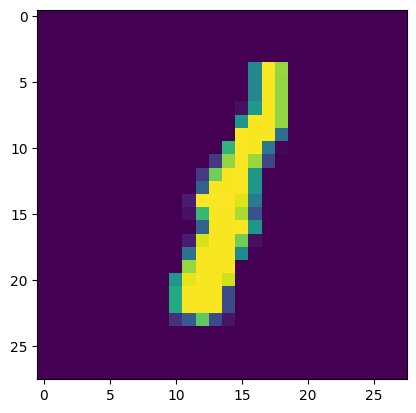

1
(28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
[[7.0963395e-11 9.9999952e-01 4.2427435e-09 6.5463267e-11 1.1552926e-07
  1.5101712e-08 7.8798497e-09 3.1144182e-07 4.2420179e-08 4.3679398e-09]]


In [32]:
n=89
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test[n,:,:,:]
print(X.shape)
X = np.expand_dims(X, axis=0)
prediction = model.predict(X)
print(prediction)

In [33]:
prediction = np.argmax(prediction)
print(prediction)

1


In [34]:
print("Сохраняем сеть")
# Сохраняем сеть для последующего использования
# Генерируем описание модели в формате json
model_json = model.to_json()
json_file = open("mnist_model_CNN.json", "w")
# Записываем архитектуру сети в файл
json_file.write(model_json)
json_file.close()
# Записываем данные о весах в файл
model.save_weights("mnist_model_CNN.weights.h5")
print("Сохранение сети завершено")

Сохраняем сеть
Сохранение сети завершено


In [35]:
from tensorflow.keras.models import model_from_json

print("Загружаю сеть из файлов")
# Загружаем данные об архитектуре сети
json_file = open("mnist_model_CNN.json", "r")
loaded_model_json = json_file.read()
json_file.close()
# Создаем модель
loaded_model = model_from_json(loaded_model_json)
# Загружаем сохраненные веса в модель
loaded_model.load_weights("mnist_model_CNN.weights.h5")
print("Загрузка сети завершена")

Загружаю сеть из файлов
Загрузка сети завершена


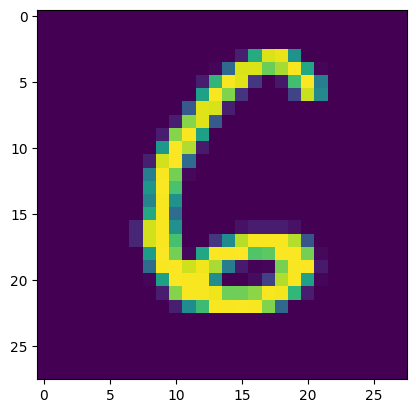

6
(28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
[[2.0514669e-08 6.7764384e-12 9.3769636e-12 2.3191557e-12 3.8425645e-11
  8.6243887e-08 9.9999988e-01 1.3831871e-15 1.2073755e-09 8.0335788e-10]]


In [36]:
n=98
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test[n,:,:,:]
print(X.shape)
X = np.expand_dims(X, axis=0)
prediction = loaded_model.predict(X)
print(prediction)

In [37]:
prediction = np.argmax(prediction)
print(prediction)

6


# Тестирование собственного изображения

(25, 25, 3)


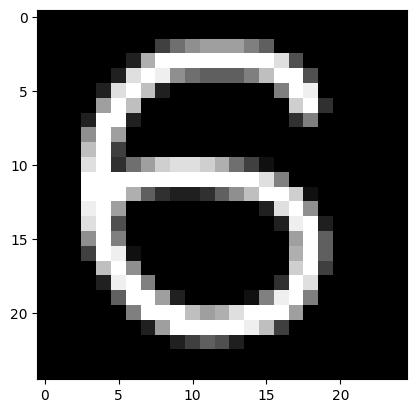

(25, 25)


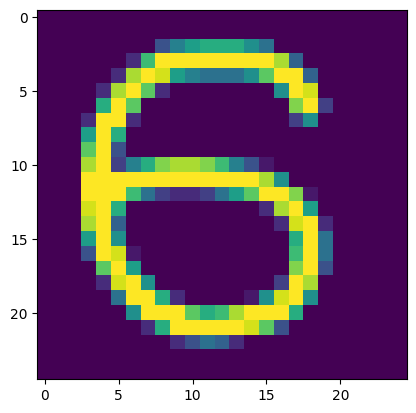

In [38]:
import cv2

#Загружаем изображение
image = cv2.imread('/content/six.png')
print(image.shape)
plt.imshow(image)
plt.show()
#Загружаем изображение в оттенках серого
image = cv2.imread('/content/six.png', cv2.IMREAD_GRAYSCALE)
print(image.shape)
#Отображение файла встроенными средствами OpenCV.
plt.imshow(image)
plt.show()

In [39]:
dim=(28,28)
resized = cv2.resize(image, dim, interpolation = cv2.INTER_AREA)
print(resized.shape)

(28, 28)


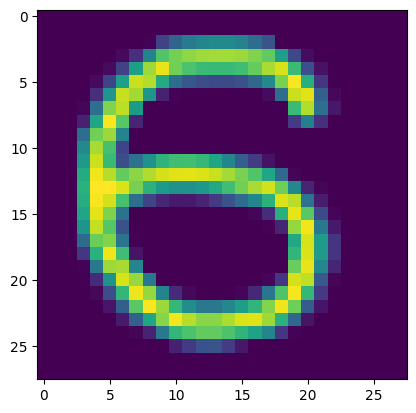

In [40]:
plt.imshow(resized.reshape(28,28))

In [41]:
resized  = resized.astype('float32')
resized = resized / 255

In [42]:
resized = np.expand_dims(resized, axis=0)
resized = np.expand_dims(resized, axis=3)
print(resized.shape)

(1, 28, 28, 1)


In [43]:
prediction = loaded_model.predict(resized)
print(prediction)
prediction = np.argmax(prediction)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[6.5473020e-02 2.2170608e-04 6.3842817e-05 1.2149059e-03 3.6912268e-05
  4.1822138e-01 5.0826597e-01 6.4056760e-05 1.4922428e-03 4.9459501e-03]]
6
